In [2]:
!nvidia-smi

Mon Oct  5 09:58:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!pip install -q diffusers transformers accelerate ultralytics transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.7 MB/s eta 0:00:00


In [2]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to(device)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

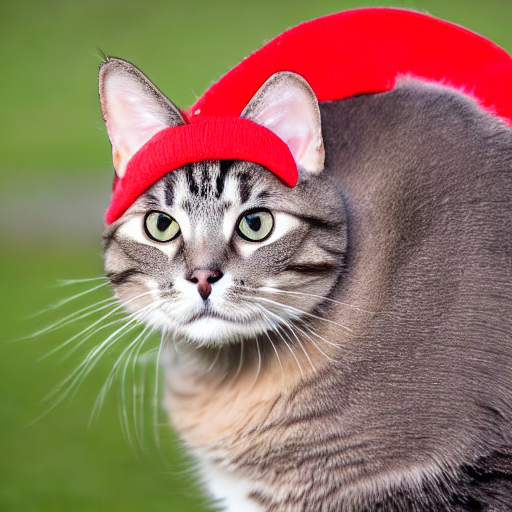

In [18]:
prompt = "a cat wearing a red hat, realistic photo"

image = pipe(prompt).images[0]
image

In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.



0: 640x640 1 cat, 11.0ms
Speed: 3.6ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


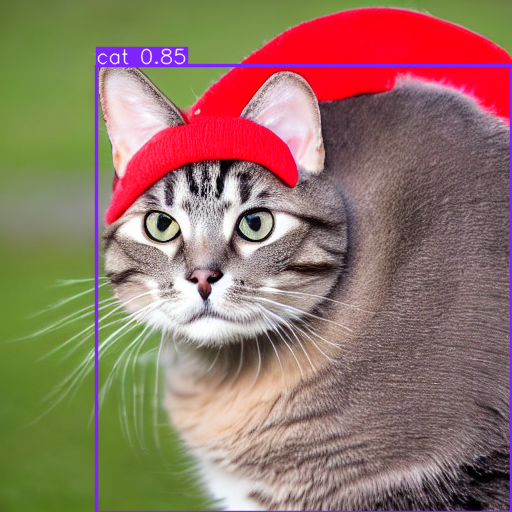

cat 0.85


In [20]:
results = model(image)
results[0].show()

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(
            model.names[class_id],
            round(confidence, 2)
        )

In [9]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

clip_model = clip_model.to(device)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [14]:
from PIL import Image

texts = [
    "a cat wearing a red hat",
    "a cat wearing a blue hat",
    "a car on a street",
    "a bowl of food on a table"
]

# img = Image.open("/content/images.jpg").convert("RGB")   # <- this line is the fix

inputs = clip_processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True
)

inputs = {key: value.to(device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = clip_model(**inputs)

probs = outputs.logits_per_image.softmax(dim=1)[0]

for text, prob in zip(texts, probs):
    print(f"{text}: {prob.item():.2%}")

a cat wearing a red hat: 99.77%
a cat wearing a blue hat: 0.23%
a car on a street: 0.00%
a bowl of food on a table: 0.00%


In [19]:
import random
import torch
import gradio as gr


def run(prompt, extra_captions, steps, guidance, seed):
    if not prompt or not prompt.strip():
        raise gr.Error("Please type a prompt first.")

    # 1) Generate the image (Stable Diffusion)
    seed = int(seed)
    if seed < 0:
        seed = random.randint(0, 2**31 - 1)
    generator = torch.Generator(device).manual_seed(seed)

    image = pipe(
        prompt,
        num_inference_steps=int(steps),
        guidance_scale=float(guidance),
        generator=generator,
    ).images[0]

    # 2) YOLO detection
    results = model(image, verbose=False)
    annotated = results[0].plot()[..., ::-1]  # BGR -> RGB
    detections = [
        [model.names[int(b.cls[0])], round(float(b.conf[0]), 3)]
        for b in results[0].boxes
    ]
    if not detections:
        detections = [["nothing detected", 0.0]]

    # 3) CLIP scores
    # captions = your prompt + any extra captions the user typed (one per line)
    extras = [l.strip() for l in (extra_captions or "").splitlines() if l.strip()]
    captions = [prompt.strip()] + extras

    inputs = clip_processor(
        text=captions, images=image,
        return_tensors="pt", padding=True, truncation=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = clip_model(**inputs)

    # which caption wins (only meaningful with 2+ captions)
    probs = out.logits_per_image.softmax(dim=1)[0].tolist()
    label_scores = {c: p for c, p in zip(captions, probs)}

    return image, annotated, detections, label_scores, seed


with gr.Blocks(title="Diffusion + YOLO + CLIP") as demo:
    gr.Markdown("# Generate an image, then check it with YOLO and CLIP")

    with gr.Row():
        with gr.Column(scale=1):
            prompt = gr.Textbox(
                label="Prompt",
                value="a cat wearing a red hat, realistic photo",
                lines=2,
            )
            extra = gr.Textbox(
                label="Extra captions to compare (optional, one per line)",
                placeholder="a cat wearing a blue hat\na dog wearing a red hat\na cat without a hat",
                lines=4,
            )
            steps = gr.Slider(10, 50, value=30, step=1, label="Steps (more = slower, better)")
            guidance = gr.Slider(1, 15, value=7.5, step=0.5, label="Guidance scale")
            seed = gr.Number(value=-1, precision=0, label="Seed (-1 = random)")
            btn = gr.Button("Generate", variant="primary")

        with gr.Column(scale=2):
            with gr.Row():
                out_img = gr.Image(label="Generated image", type="pil")
                out_yolo = gr.Image(label="YOLO detections")
            out_table = gr.Dataframe(headers=["object", "confidence"], label="YOLO objects")
            out_label = gr.Label(label="CLIP: which caption fits best?")
            out_seed = gr.Number(label="Seed used (reuse it to get the same image)", precision=0)

    btn.click(
        run,
        inputs=[prompt, extra, steps, guidance, seed],
        outputs=[out_img, out_yolo, out_table, out_label, out_seed],
    )

demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://cf52e1d7d87ccae04d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/30 [00:00<?, ?it/s]

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cf52e1d7d87ccae04d.gradio.live
